In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import numpy as np


In [9]:
df = pd.read_excel('data_agrohom/150925_extraction_agrohom.xlsx')

In [5]:
#df['Country of corresponding author'].value_counts()

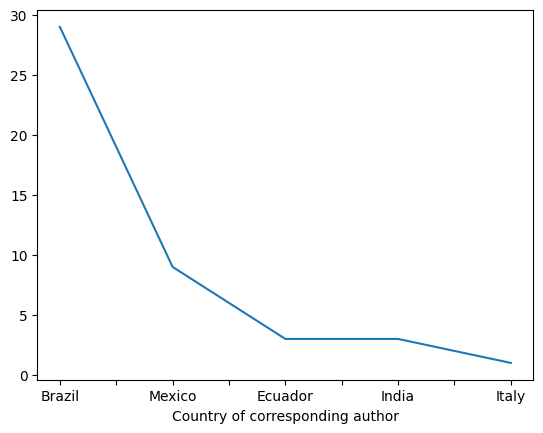

In [5]:
# # Create a working copy to avoid altering the original DataFrame
# df2 = df.copy()
#
# # Keep only rows where the blinding status is explicitly 'Not blinded'
# df2 = df2[df2.Blinded == 'Not blinded']
#
# # Compute counts of the 'Country of corresponding author' within the filtered data
# counts = df2['Country of corresponding author'].value_counts()
#
# # Plot the counts (returns an Axes object; stored in 'fig' for consistency with existing code)
# fig = counts.plot()
#
# # Save the plot to a PNG file in the current working directory
# plt.savefig('corresponding.png')


In [6]:
print(df.columns)

Index(['Done', 'Study # within same publication', 'Covidence #',
       'Study ID (as in covidence)', 'Title (covidence)', 'MIS score',
       'Reviewer Name', 'Title', 'First author SURNAME only',
       'Year of publication', 'DOI', 'Country of corresponding author',
       'Language of full article', 'How many studies in this publictaion?',
       'Replication study', 'If replication, write here which publication',
       'Blinded', 'Physical allocation', 'Setting in which treated',
       'Growth infrastructure', 'Soil characteristics, if given (free text)',
       'Crop type studied', 'Species, variety/cultivar ',
       'Main biological system studied', 'Parallel interventions applied',
       'Homeopathic intervention', 'Remedy/remedies ', 'Potency levels',
       'Reason for choosing remedy & hypothesis for application of the remedy',
       'Reason for choosing remedy level(s)', 'Production of potency',
       'Materials for potentization', 'Controls',
       'Control for inte

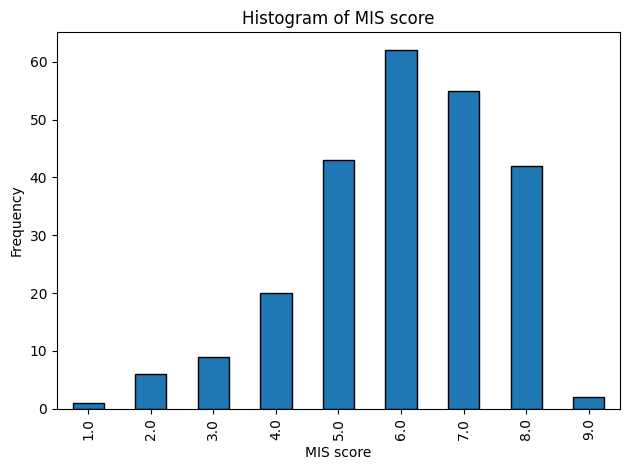

In [7]:
# Compute distribution of MIS scores (excluding missing values) and sort by score
MIS_counts = df['MIS score'].dropna().value_counts().sort_index()

# Plot the bar chart of MIS score frequencies
MIS_his = MIS_counts.plot.bar(edgecolor='black')

# Label the axes and set the title
MIS_his.set_xlabel('MIS score')
MIS_his.set_ylabel('Frequency')
MIS_his.set_title('Histogram of MIS score')

# Save the histogram as a PNG file
MIS_his.figure.tight_layout()
MIS_his.figure.savefig('mis_histogram.png', dpi=300, bbox_inches='tight')

In [ ]:
# Compute distribution of publication years with a "<2000" bin and ensure all years 2000-2025 are present
# NB! DOES NOT COUNT MISSING VALUES

years_clean = pd.to_numeric(df['Year of publication'], errors='coerce').dropna().astype(int)
year_labels = years_clean.map(lambda y: '<2000' if y < 2000 else str(y))
year_counts = year_labels.value_counts()

# Ensure all desired categories are present (fill missing with 0)
categories = ['<2000'] + [str(y) for y in range(2000, 2026)]
year_counts = year_counts.reindex(categories, fill_value=0)

# Plot the bar chart of year frequencies
year_hist = year_counts.loc[categories].plot.bar(edgecolor='black')

# Label the axes and set the title
year_hist.set_xlabel('Year')
year_hist.set_ylabel('Number of publications')
year_hist.set_title('Publication frequency by year')

# Save the histogram as a PNG file
year_hist.figure.tight_layout()
year_hist.figure.savefig('year_histogram.png', dpi=300, bbox_inches='tight')


In [50]:
# Pie chart for "Country of corresponding author" with country names and % contributions.
# Countries contributing <10% have labels placed outside with leader lines for visibility.
# Smallest countries are combined into "Other".

# Prepare data
country_series = (
    df['Country of corresponding author']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({
        'Parkistan': 'Pakistan'
    })
    .replace({
        'Great Britain': 'Other',
        'Serbia': 'Other',
        'Romania': 'Other'
    })
)

country_counts = country_series.value_counts()
labels = country_counts.index.tolist()
values = country_counts.values.tolist()

# Compute percentages and set label positions
total = sum(values)
percentages = [(v / total) * 100 if total else 0 for v in values]
text_positions = ['outside' if p < 10 else 'inside' for p in percentages]

# Build pie chart (Plotly shows leader lines automatically for outside labels)
country_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels,
            values=values,
            textinfo='label+percent',
            textposition=text_positions,
            hovertemplate='%{label}: %{percent} (%{value})<extra></extra>',
            sort=False,
            direction='clockwise',
            rotation=90,

        )
    ]
)

country_pie.update_traces(textfont_size=12, marker=dict(line=dict(color='white', width=1)))
country_pie.update_layout(
    title='Country of corresponding author',
    showlegend=False,
    margin=dict(t=60, b=20, l=20, r=20)
)

country_pie.show()      #Plotly figures are data objects when created, call .show() to display them

#Save the figure as a PNG file. Note: matplotlib uses .figure.savefig(), plotly uses .write_image().
country_pie.write_image('country_pie.png', width=800, height=600, scale=2)

<llm-snippet-file>/Users/anezkasokol/Dropbox/AgroHomeo Review/Analysis/python_code_agrohom/my_first_analysis.ipynb</llm-snippet-file>


<llm-snippet-file>/Users/anezkasokol/Dropbox/AgroHomeo Review/Analysis/python_code_agrohom/my_first_analysis.ipynb</llm-snippet-file>


In [16]:
# Pie chart for "Language of full article" with language names and % contributions.
# Labels for slices <10% are placed outside for readability.

# Prepare data
language_series = (
    df['Language of full article']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)


# SPECIAL CASE re-labeling/normalization:
# - This is a dataset-specific cleanup to standardize mixed-language entries.
# - We treat '&' as equivalent to '+' and canonicalize the order of languages
#   so that permutations like "English+Spanish" and "Spanish+English" map to the same label.
def _normalize_language_label(s: str) -> str:
    if not s or s.lower() == 'unknown':
        return 'Unknown'
    # SPECIAL CASE: normalize separator
    s = s.replace('&', '+')
    parts = [p.strip().title() for p in s.split('+') if p.strip()]
    if not parts:
        return 'Unknown'
    # SPECIAL CASE: sort to combine permutations like "English+Spanish" and "Spanish+English"
    parts = sorted(dict.fromkeys(parts))  # remove duplicates and sort
    return '+'.join(parts) if len(parts) > 1 else parts[0]


# Apply the special-case normalization to the language labels
language_series = language_series.apply(_normalize_language_label)

language_counts = language_series.value_counts()
lang_labels = language_counts.index.tolist()
lang_values = language_counts.values.tolist()

# Compute percentages and set label positions
lang_total = sum(lang_values)
lang_percentages = [(v / lang_total) * 100 if lang_total else 0 for v in lang_values]
lang_text_positions = ['outside' if p < 10 else 'inside' for p in lang_percentages]

# Build pie chart with style similar to the country chart
language_pie = go.Figure(
    data=[
        go.Pie(
            labels=lang_labels,
            values=lang_values,
            textinfo='label+percent',
            textposition=lang_text_positions,
            hovertemplate='%{label}: %{percent} (%{value})<extra></extra>',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

language_pie.update_traces(textfont_size=12, marker=dict(line=dict(color='white', width=1)))
language_pie.update_layout(
    title='Language of full article',
    showlegend=False,
    margin=dict(t=60, b=20, l=20, r=20)
)

language_pie.show()
language_pie.write_image('language_pie.png', width=800, height=600, scale=2)


In [6]:
# NB! Not true data!!!
# Leader lines dont seem to work. For very small slices, separating the slice slightly (pull)
# makes the connector line visible and avoids overlap.
ironic_replications = go.Figure(data=[go.Pie(
    labels=['Single studies', 'Actual replications', 'Studies replicating a same drug on other plant system'],
    values=[148, 0, 1],         #MADE UP DATA
    textinfo='label+percent',
    textposition=['inside', 'none', 'outside'],
    pull=[0, 0, 0.08],  # separate the tiny slice 
    hovertemplate='%{label}: %{value} studies<extra></extra>'
)])

ironic_replications.update_traces(textfont_size=12, marker=dict(line=dict(color='white', width=1)))
ironic_replications.update_layout(
    margin=dict(t=60, b=20, l=20, r=20)
)

ironic_replications.show()
ironic_replications.write_image('replications.png', width=800, height=600, scale=2)


In [48]:
# DISCUSS: Single & double blinded, if it makes sense.
# Pie chart for "Blinded" with all labels kept (no grouping), styled like the language chart.

# Prepare data
blinded_series = (
    df['Blinded']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)

blinded_counts = blinded_series.value_counts()
blinded_labels = blinded_counts.index.tolist()
blinded_values = blinded_counts.values.tolist()

# Compute percentages and set label positions
blinded_total = sum(blinded_values)
blinded_percentages = [(v / blinded_total) * 100 if blinded_total else 0 for v in blinded_values]
blinded_text_positions = ['outside' if p < 10 else 'inside' for p in blinded_percentages]

# Build pie chart with style similar to the language chart
blinded_pie = go.Figure(
    data=[
        go.Pie(
            labels=blinded_labels,
            values=blinded_values,
            textinfo='label+percent',
            textposition=blinded_text_positions,
            hovertemplate='%{label}: %{percent} (%{value})<extra></extra>',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

blinded_pie.update_traces(textfont_size=12, marker=dict(line=dict(color='white', width=1)))
blinded_pie.update_layout(
    title='Blinded',
    showlegend=False,
    margin=dict(t=60, b=20, l=20, r=20)
)

blinded_pie.show()
blinded_pie.write_image('blinded_pie.png', width=800, height=600, scale=2)


In [40]:
df['Setting in which treated'].dropna().value_counts().sort_index()



Setting in which treated
Farm / open fields                                                            47
Farm / open fields, Greenhouse open                                            1
Greenhouse clima controlled                                                   10
Greenhouse clima controlled, Microbiological experiment                        1
Greenhouse open                                                               17
Greenhouse open, Indoor unspecific                                             1
Greenhouse unspecific                                                         32
Greenhouse unspecific, Farm / open fields                                      2
Greenhouse unspecific, Greenhouse clima controlled                             2
Greenhouse unspecific, Greenhouse open                                         1
Greenhouse unspecific, N/A or not relevant                                     1
Indoor clima controlled                                                       17
Ind

<llm-snippet-file>/Users/anezkasokol/Dropbox/AgroHomeo Review/Analysis/python_code_agrohom/my_first_analysis.ipynb</llm-snippet-file>


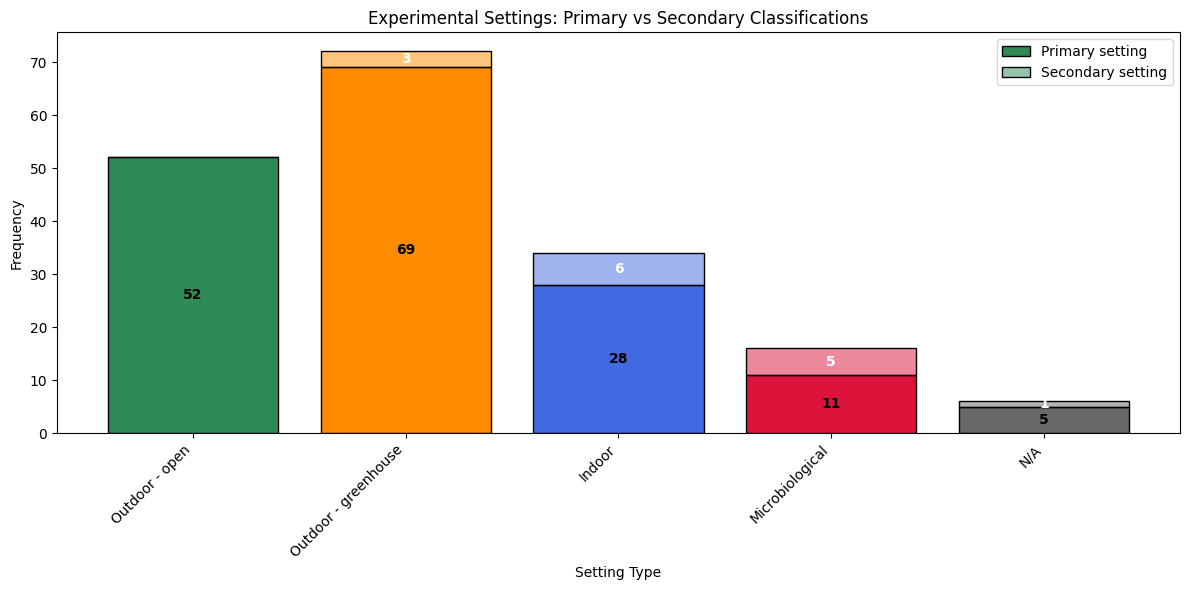

In [44]:

# Setting in which treated bar chart. Makes a chart with the first bar being Outdoor - open (most open) and so forth (less open, more controlled). If a study has multiple settings, it counts in multiple bars, but any secondary (or third...) settings are counted in the secondary bars on top. This primary/secondary is prioritized according to the same order from most open to least open.

# Create mapping dictionary
mapping = {
    'Farm / open fields': 'Outdoor - open',
    'Greenhouse clima controlled': 'Outdoor - greenhouse',
    'Greenhouse open': 'Outdoor - greenhouse',
    'Greenhouse unspecific': 'Outdoor - greenhouse',
    'Indoor clima controlled': 'Indoor',
    'Indoor unspecific': 'Indoor',
    'Microbiological experiment': 'Microbiological',
    'N/A or not relevant': 'N/A'
}

# Define categories in order of importance
categories = ['Outdoor - open', 'Outdoor - greenhouse', 'Indoor', 'Microbiological', 'N/A']

# Initialize counters
primary_counts = {cat: 0 for cat in categories}
secondary_counts = {cat: 0 for cat in categories}

# Process each entry
for entry in df['Setting in which treated'].dropna():
    # Split by comma and strip whitespace
    settings = [s.strip() for s in entry.split(',')]

    # Map each setting to category
    mapped_settings = []
    for setting in settings:
        if setting in mapping:
            mapped_settings.append(mapping[setting])

    if mapped_settings:
        # First category (highest priority) goes to primary
        primary_category = None
        for cat in categories:  # Check in order of importance
            if cat in mapped_settings:
                primary_category = cat
                break

        if primary_category:
            primary_counts[primary_category] += 1

            # Remaining categories go to secondary
            remaining = [cat for cat in mapped_settings if cat != primary_category]
            for cat in remaining:
                secondary_counts[cat] += 1

# Create the plot
settings_bar, ax = plt.subplots(figsize=(12, 6))

# Define colors (dark and light versions)
colors = {
    'Outdoor - open': '#2E8B57',  # Sea Green
    'Outdoor - greenhouse': '#FF8C00',  # Dark Orange
    'Indoor': '#4169E1',  # Royal Blue
    'Microbiological': '#DC143C',  # Crimson
    'N/A': '#696969'  # Dim Gray
}

light_colors = {cat: color + '80' for cat, color in colors.items()}  # Add transparency

x_pos = np.arange(len(categories))

# Plot primary bars
primary_values = [primary_counts[cat] for cat in categories]
bars1 = ax.bar(x_pos, primary_values, color=[colors[cat] for cat in categories],
               label='Primary setting', edgecolor='black')

# Plot secondary bars on top
secondary_values = [secondary_counts[cat] for cat in categories]
bars2 = ax.bar(x_pos, secondary_values, bottom=primary_values,
               color=[light_colors[cat] for cat in categories],
               label='Secondary setting', edgecolor='black')

# Customize the plot
ax.set_xlabel('Setting Type')
ax.set_ylabel('Frequency')
ax.set_title('Experimental Settings: Primary vs Secondary Classifications')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend()

# Add value labels on bars
for i, (p, s) in enumerate(zip(primary_values, secondary_values)):
    if p > 0:
        ax.text(i, p / 2, str(p), ha='center', va='center', fontweight='bold')
    if s > 0:
        ax.text(i, p + s / 2, str(s), ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
settings_bar.savefig('settings_bar.png', dpi=300, bbox_inches='tight')
plt.show()


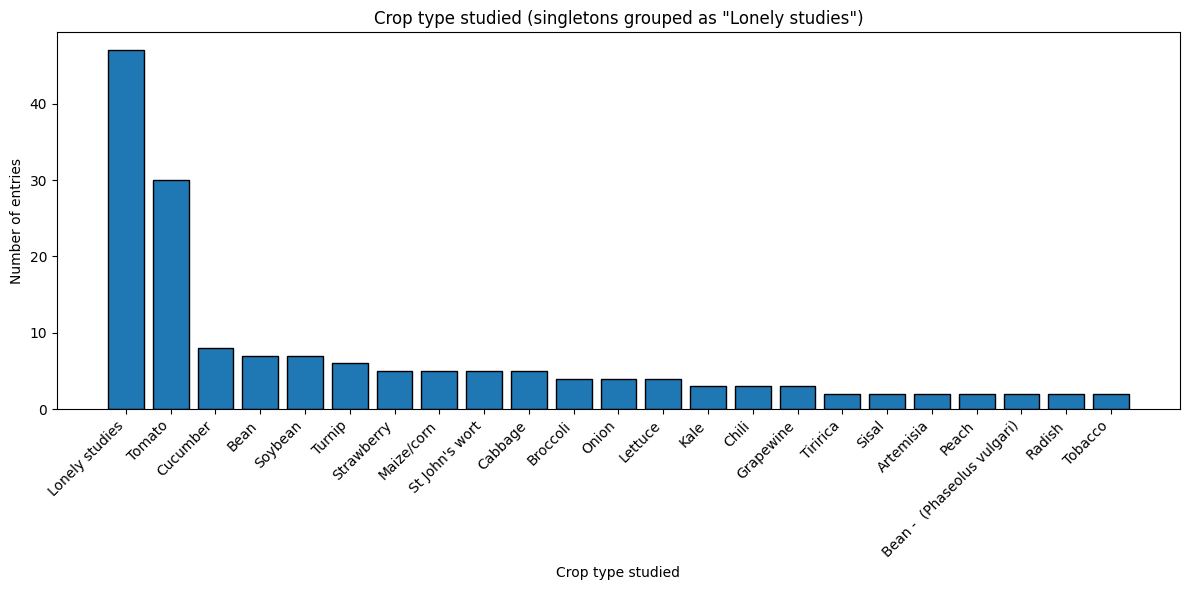

In [14]:
# Analyze and visualize the distribution of "Crop type studied" with all singletons grouped as "Lonely studies".
# Steps:
# 1) Clean the "Crop type studied" column (drop missing, ensure strings, trim spaces).
# 2) Count occurrences of each unique crop type.
# 3) Group all categories that appear only once (singletons) under a single label "Lonely studies".
# 4) Sort by frequency (descending) and plot a bar chart.
# 5) Save the figure as a PNG and display it.

# 1) Clean the source series
crop_series = df['Crop type studied'].dropna().astype(str).str.strip()

# 2) Raw counts by crop type
crop_counts = crop_series.value_counts()

# 3) Group all singletons under "Lonely studies"
lonely_mask = crop_counts == 1  # True for categories that appear exactly once
lonely_count = int(crop_counts[lonely_mask].sum())  # Total number of singleton entries (studies)
grouped_counts = crop_counts[~lonely_mask].copy()  # Keep non-singletons as-is
if lonely_count > 0:
    grouped_counts.loc['Lonely studies'] = lonely_count

# 4) Sort for plotting
grouped_counts = grouped_counts.sort_values(ascending=False)

# 5) Plot bar chart
# Use matplotlib directly
fig, crop_bar = plt.subplots(figsize=(12, 6))
bars = crop_bar.bar(range(len(grouped_counts)), grouped_counts.values, edgecolor='black')
crop_bar.set_xticks(range(len(grouped_counts)))
crop_bar.set_xticklabels(grouped_counts.index, rotation=45, ha='right')
crop_bar.set_xlabel('Crop type studied')
crop_bar.set_ylabel('Number of entries')
crop_bar.set_title('Crop type studied (singletons grouped as "Lonely studies")')

# Save and show
crop_bar.figure.tight_layout()
crop_bar.figure.savefig('crop_type_bar.png', dpi=300, bbox_inches='tight')
plt.show()


Task: Create a pie chart like the "Country of corresponding author" chart for the column "Main biological system studied". Split multiple systems separated by commas and count each individually, except keep "Harvest (fruit, grains, tubers)" as a single, unsplit category.

In [24]:

# PIE CHART: "Main biological system studied"
# Goal:
# - Split comma-separated entries so each system is counted individually.
# - Preserve the phrase "Harvest (fruit, grains, tubers)" as one unit (do not split it).
# - Display a clean pie chart with percentages and a clear, informative title.

# 1) Normalize and clean the source column
bio_series = (
    df['Main biological system studied']  # source column
    .fillna('N/A')  # fill missing as 'Unknown'
    .astype(str)  # ensure string type
    .str.strip()  # trim whitespace
    .replace({'': 'Unknown'})  # safeguard empty strings
)

# 2) Protect the multi-word phrase so it doesn't get split by commas
protected_phrase = 'Harvest (fruit, grains, tubers)'
protected_placeholder = 'Harvest (fruit-grains-tubers)'  # temporary replacement (semicolons)

# Replace the protected phrase with a placeholder before splitting
bio_series = bio_series.str.replace(protected_phrase, protected_placeholder, regex=False)

# 3) Split by comma, explode into one value per row, and clean up
bio_exploded = (
    bio_series
    .str.split(',')  # split comma-separated values
    .explode()  # one value per row
    .astype(str)
    .str.strip()
)

# Restore the protected phrase and handle any remaining empties
bio_exploded = bio_exploded.replace({'': 'N/A', protected_placeholder: protected_phrase})

# 4) Aggregate counts and prepare labels/values
bio_counts = bio_exploded.value_counts()
bio_labels = bio_counts.index.tolist()
bio_values = bio_counts.values.tolist()

# 4b) Define intuitive colors matching labels
color_map = {
    'Adult plants': '#1b7837',  # dark green (mature plants)
    'Seedling': '#5aae61',  # medium green (young plants)
    'Seed': '#a6dba0',  # light green (seeds)
    'Cutlings': '#ccebc5',  # pale green (cuttings)
    'Harvest (fruit, grains, tubers)': '#fdae61',  # harvest -> golden/orange
    '"Harvest (fruit-grains-tubers)"': '#fdae61',  # safeguard variant in data
    'Fungus': '#762a83',  # purple (fungi)
    'Bacteria': '#2b8cbe',  # blue (bacteria)
    'Animal (eg. insect)': '#d95f02',  # orange (insects/animals)
    'Soil': '#8c510a',  # brown (soil)
    'Run-overs': '#969696',  # gray (misc/other)
    'N/A': '#bdbdbd'  # light gray (unknown)
}
bio_colors = [color_map.get(lbl, '#cccccc') for lbl in bio_labels]

# 5) Compute percentages and decide label placement (outside for small slices)
bio_total = int(sum(bio_values))
bio_percentages = [(v / bio_total) * 100 if bio_total else 0 for v in bio_values]
bio_text_positions = ['outside' if p < 10 else 'inside' for p in bio_percentages]

# 6) Build the Plotly pie chart
bio_pie = go.Figure(
    data=[
        go.Pie(
            labels=bio_labels,
            values=bio_values,
            textinfo='label+percent',  # show label and percent on the slice/leader line
            textposition=bio_text_positions,  # inside for large slices, outside for small ones
            hovertemplate='%{label}: %{percent} (%{value})<extra></extra>',  # detailed hover
            sort=False,  # keep current order (by frequency)
            direction='clockwise',
            rotation=90,  # start at 12 o'clock
            marker=dict(colors=bio_colors, line=dict(color='white', width=1))
        )
    ]
)

# 7) Style and title (include N and note multi-selection)
bio_pie.update_traces(
    textfont_size=12,
    marker=dict(line=dict(color='white', width=1))  # subtle white stroke between slices
)
bio_pie.update_layout(
    title=f'Main Biological System Studied (N={bio_total})',
    showlegend=False,
    margin=dict(t=70, b=20, l=20, r=20)
)

# 8) Render and export
bio_pie.show()
bio_pie.write_image('main_bio_system_pie.png', width=800, height=600, scale=2)


<llm-snippet-file>/Users/anezkasokol/Dropbox/AgroHomeo Review/Analysis/python_code_agrohom/my_first_analysis.ipynb</llm-snippet-file>


In [45]:
# PIE CHART: "Parallel interventions applied"
# Purpose:
# - Normalize the "Parallel interventions applied" column
# - Map granular entries to broader, report-friendly categories
# - Split multi-valued cells and count each intervention individually
# - Visualize the grouped distribution with clear labeling and a descriptive title

# 1) Clean and standardize the source column
parallel_series = (
    df['Parallel interventions applied']
    .fillna('N/A')  # replace missing with explicit 'N/A'
    .astype(str)  # ensure strings
    .str.strip()  # trim whitespace
)

# 2) Mapping from raw entries to grouped categories
mapping = {
    'Chemical fertilizers': 'Chemical (fertilizers, pesticides)',
    'Chemical pest control or antibiotics': 'Chemical (fertilizers, pesticides)',
    'Seed sanitazion with chlorine/HgCl2/alcohol or similar': 'Chemical (fertilizers, pesticides)',
    'Manure or organic fertilizers': 'Organic (manure, organic fertilizers)',
    'Active inoculation with microbiotic pathogen': 'Biological (inoculation, insects)',
    'Active application of insects/nymphs': 'Biological (inoculation, insects)',
    'Active inoculation with microbiotic pathogen as part of factorial design': 'Biological (inoculation, insects)',
    'Catch crop': 'Biological (inoculation, insects)',
    'Salt-stress': 'Stress treatments (heat, salt, water, metals)',
    'Heat-stress': 'Stress treatments (heat, salt, water, metals)',
    'Water-stress': 'Stress treatments (heat, salt, water, metals)',
    'Salt-stress as part of factorial design': 'Stress treatments (heat, salt, water, metals)',
    'Aluminium-stress': 'Stress treatments (heat, salt, water, metals)',
    'Heavy metal-stress': 'Stress treatments (heat, salt, water, metals)',
    'None': 'None',
    'N/A': 'N/A',
}

# 3) Split cells on comma, explode to rows, trim, and coerce empties to 'N/A'
entries = (
    parallel_series
    .str.split(',')  # split multiple interventions
    .explode()  # count each intervention separately
    .astype(str)
    .str.strip()
    .replace({'': 'N/A'})
)

# 4) Apply grouping (keep any unmapped entries as-is to surface unexpected values)
grouped = entries.map(lambda x: mapping.get(x, x))

# 5) Define a preferred display order; keep any unexpected categories after these
order = [
    'Biological (inoculation, insects)',
    'Chemical (fertilizers, pesticides)',
    'Stress treatments (heat, salt, water, metals)',
    'Organic (manure, organic fertilizers)',
    'None',
    'N/A'
]

# 6) Count and reorder for presentation
grouped_counts = grouped.value_counts()
ordered_index = [c for c in order if c in grouped_counts.index] + [c for c in grouped_counts.index if c not in order]
grouped_counts = grouped_counts.reindex(ordered_index)

# 7) Prepare data for the pie chart
labels = grouped_counts.index.tolist()
values = grouped_counts.values.tolist()
total = int(sum(values)) if len(values) else 0

# Place labels outside if the slice is small to improve readability (threshold: 11%)
percentages = [(v / total) * 100 if total else 0 for v in values]
text_positions = ['outside' if p < 11 else 'inside' for p in percentages]

# 8) Build the pie chart (styled consistently with the "Country of corresponding author" chart)
parallel_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels,
            values=values,
            textinfo='label+percent',
            textposition=text_positions,
            hovertemplate='%{label}: %{percent} (%{value})<extra></extra>',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

# 9) Styling and a descriptive title including N and methodological notes
parallel_pie.update_traces(textfont_size=12, marker=dict(line=dict(color='white', width=1)))
parallel_pie.update_layout(
    title=f'Parallel interventions applied'
          f'<br><sup>Grouped categories; multi-selections counted individually; N={total}</sup>',
    showlegend=False,
    margin=dict(t=80, b=20, l=20, r=20)
)

# 10) Display and export
parallel_pie.show()
parallel_pie.write_image('parallel_interventions_applied_pie.png', width=800, height=600, scale=2)
